In [76]:
import pandas as pd
import numpy as np
import json
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc


In [77]:
with open("training dataset/tabular/engineered_feature_groups.json") as f:
    feature_groups = json.load(f)

phase1_features = (
    feature_groups["Clinical"] +
    feature_groups["Demographic / Other"] +
    feature_groups["Laboratory"] +
    feature_groups["Scoring"] +
    feature_groups["clinical_derived"] +
    feature_groups["lab_derived"]
)

print("Total Phase 1 candidate features:", len(phase1_features))


Total Phase 1 candidate features: 50


In [78]:
train_df = pd.read_csv("training dataset/tabular/train_split.csv")
val_df   = pd.read_csv("training dataset/tabular/val_split.csv")
test_df  = pd.read_csv("training dataset/tabular/test_split.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (546, 103)
Val shape: (78, 103)
Test shape: (157, 103)


In [79]:
available_features = [f for f in phase1_features if f in train_df.columns]

print("Final features used:", len(available_features))


Final features used: 50


In [80]:
X_train = train_df[available_features]
X_val   = val_df[available_features]
X_test  = test_df[available_features]

y_train = train_df["Diagnosis"]
y_val   = val_df["Diagnosis"]
y_test  = test_df["Diagnosis"]


In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [82]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(1.2352941176470589), np.int64(1): np.float64(0.84)}


In [83]:
def build_large_mlp(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(64, activation="relu")(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)
    embedding = tf.keras.layers.Dense(32, activation="relu", name="clinical_embedding")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(embedding)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

large_mlp = build_large_mlp(X_train.shape[1])
large_mlp.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_embedding (Dense)      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
def build_small_mlp(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(32, activation="relu")(inputs)
    embedding = tf.keras.layers.Dense(16, activation="relu", name="clinical_embedding")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(embedding)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

small_mlp = build_small_mlp(X_train.shape[1])
small_mlp.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_embedding (Dense)      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [86]:
history_large = large_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],   # remove if not needed
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6026 - auc: 0.6420 - loss: 0.6703 - val_accuracy: 0.6538 - val_auc: 0.6827 - val_loss: 0.6392
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7179 - auc: 0.7836 - loss: 0.5605 - val_accuracy: 0.6538 - val_auc: 0.6929 - val_loss: 0.6337
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7179 - auc: 0.7933 - loss: 0.5472 - val_accuracy: 0.6667 - val_auc: 0.7072 - val_loss: 0.6331
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7399 - auc: 0.8332 - loss: 0.4979 - val_accuracy: 0.6795 - val_auc: 0.7154 - val_loss: 0.6449
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7491 - auc: 0.8406 - loss: 0.4881 - val_accuracy: 0.7051 - val_auc: 0.7293 - val_loss: 0.6368
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7564 - auc: 0.8575 - loss: 0.4618 - val_accuracy: 0.7051 - val_auc: 0.7242 - val_loss: 0.6424
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

In [87]:
history_small = small_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5256 - auc: 0.5053 - loss: 0.7482 - val_accuracy: 0.6282 - val_auc: 0.7133 - val_loss: 0.6170
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6795 - auc: 0.7576 - loss: 0.5946 - val_accuracy: 0.6667 - val_auc: 0.7503 - val_loss: 0.5958
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7289 - auc: 0.8090 - loss: 0.5366 - val_accuracy: 0.7179 - val_auc: 0.7500 - val_loss: 0.5849
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7399 - auc: 0.8307 - loss: 0.5035 - val_accuracy: 0.7692 - val_auc: 0.7500 - val_loss: 0.5905
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7546 - auc: 0.8453 - loss: 0.4823 - val_accuracy: 0.7692 - val_auc: 0.7629 - val_loss: 0.5889
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7582 - auc: 0.8576 - loss: 0.4636 - val_accuracy: 0.7564 - val_auc: 0.7615 - val_loss: 0.5890
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

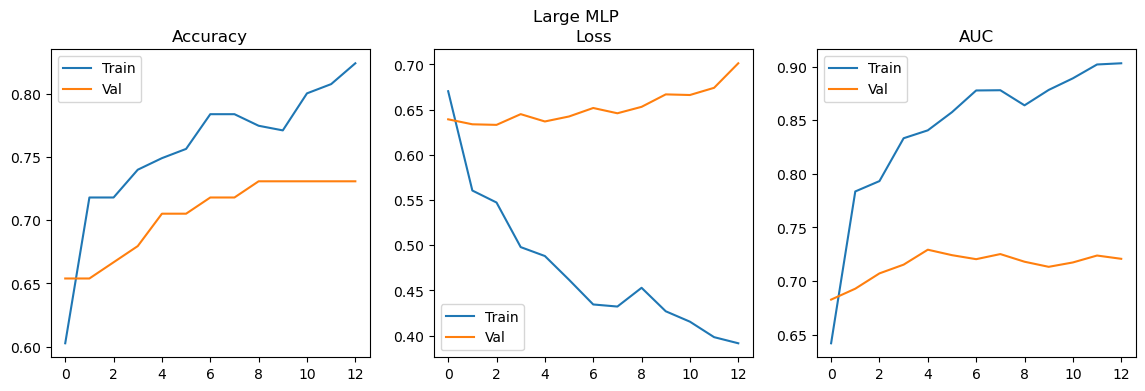

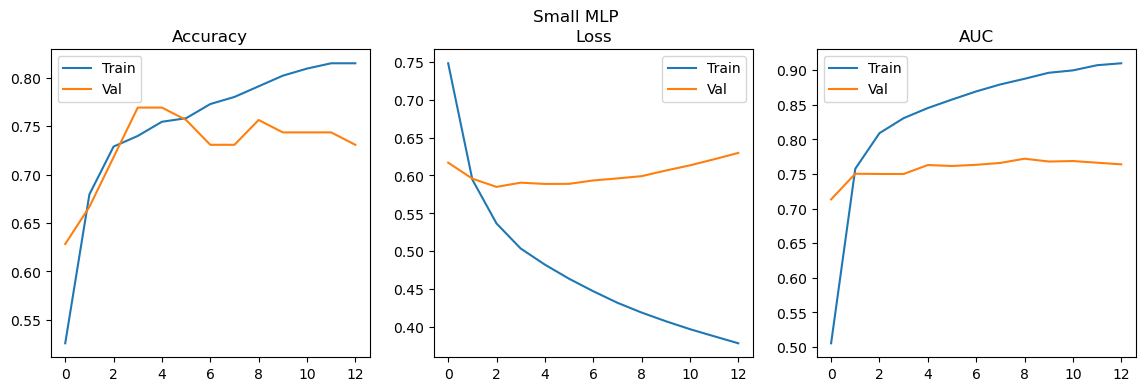

In [88]:
def plot_history(history, title):
    plt.figure(figsize=(14,4))

    # Accuracy
    plt.subplot(1,3,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,3,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title("Loss")
    plt.legend()

    # AUC
    plt.subplot(1,3,3)
    plt.plot(history.history["auc"], label="Train")
    plt.plot(history.history["val_auc"], label="Val")
    plt.title("AUC")
    plt.legend()

    plt.suptitle(title)
    plt.show()

plot_history(history_large, "Large MLP")
plot_history(history_small, "Small MLP")


In [89]:
def evaluate_model(model, name):
    loss, acc, auc_score = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} → Accuracy: {acc:.3f}, AUC: {auc_score:.3f}")

evaluate_model(large_mlp, "Large MLP")
evaluate_model(small_mlp, "Small MLP")


Large MLP → Accuracy: 0.707, AUC: 0.744
Small MLP → Accuracy: 0.682, AUC: 0.766


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


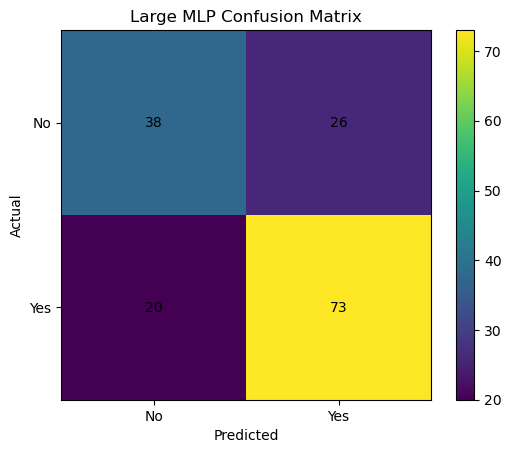

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/stepWARNING:tensorflow:5 out of the last 21 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000027350F95620> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


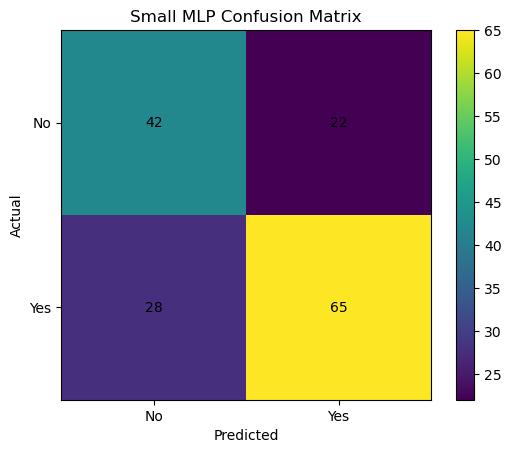

In [90]:
def plot_confusion(model, title):
    preds = (model.predict(X_test).ravel() > 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)

    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0,1], ["No", "Yes"])
    plt.yticks([0,1], ["No", "Yes"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(large_mlp, "Large MLP Confusion Matrix")
plot_confusion(small_mlp, "Small MLP Confusion Matrix")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


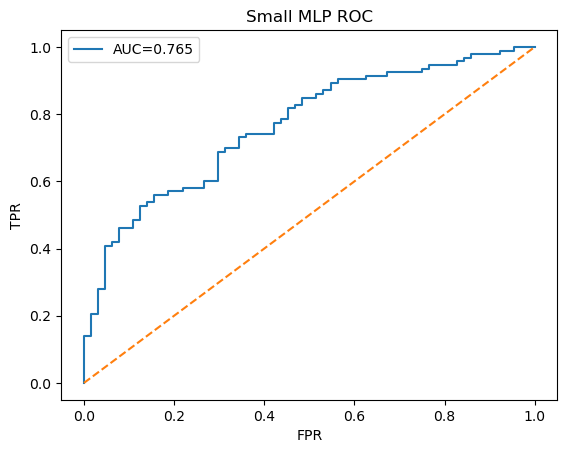

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


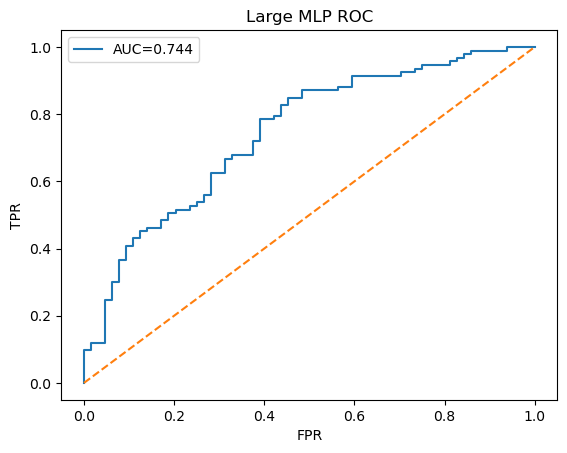

In [93]:
def plot_roc(model, title):
    probs = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

plot_roc(small_mlp, "Small MLP ROC")
plot_roc(large_mlp, "Large MLP ROC")


In [92]:
feature_extractor = tf.keras.Model(
    inputs=small_mlp.inputs,
    outputs=small_mlp.get_layer("clinical_embedding").output
)

train_embeddings = feature_extractor.predict(X_train)
val_embeddings   = feature_extractor.predict(X_val)
test_embeddings  = feature_extractor.predict(X_test)

print("Embedding shape:", train_embeddings.shape)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Embedding shape: (546, 16)
